# 12 · Stress testing v2 — corrected arithmetic, breakpoints, Monte Carlo and the B4 trend alternative

### What was wrong with notebooks 08 / 09
| # | Issue | Effect on the reported numbers |
|---|---|---|
| 1 | **Premium held at the base expected premium** while renewal probability was shocked (both notebooks) | a lapse shock removed accounts from retention but not their premium |
| 2 | **Claims not re-weighted by the shocked probability** (notebook 08) | "mild adverse" and "moderate adverse" gave identical claims |
| 3 | **B4 claims = the whole FY2025 book × trend, not × renewal probability** (both) | ~100% of claims were set against ~91% of premium, so MLR jumped to **103.8% / 104.1%**. Correctly weighted, the no-reprice B4 MLR is in the high 80s |
| 4 | Additive, clipped shocks `clip(p + shock)` | uniform across accounts, so no adverse selection (in reality the healthy, price-sensitive accounts leave first) |
| 5 | Pass/fail on the 80–85% corridor for a +10% claims shock | with a 5-pt corridor no rate set can pass both +10% claims and the 80% floor; the right output is a **breakpoint** and a **re-pricing trigger**, not a fail flag |

Plus the design issue fixed in notebook 11: v1 rates sat at exactly 80.000% retention, so every adverse retention scenario failed by construction.

Primary case, as the README requires: FY2025 paid claims carried forward, **no B4 trend**. B4 is used only in the separately reported trend scenarios.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' if (ROOT / 'data').exists() else ROOT   # raw input files
sys.path.insert(0, str(ROOT / 'notebooks'))
from trackA_v2_utils import RATES, RenewalStress, portfolio_metrics, monte_carlo, summarise_mc, solve_rate_mip

M, O = ROOT / 'outputs' / 'v2' / '01_renewal_model', ROOT / 'outputs' / 'v2' / '02_optimisation'
OUT = ROOT / 'outputs' / 'v2' / '03_stress_testing'; (OUT / 'plots').mkdir(parents=True, exist_ok=True)
G = np.load(M / 'grid_2026_v2.npz', allow_pickle=True); snap = pd.read_csv(M / 'account_snapshot_2026_v2.csv')
P, Zg, beta, draws = G['P'], G['Zg'], G['beta'], G['beta_draws']
prem0, claims0, cv = snap['annual_premium_2025'].to_numpy(), snap['paid_claims_2025'].to_numpy(), snap['process_cv'].to_numpy()
N = len(snap); i = np.arange(N)
stress = RenewalStress(Zg, beta, G['rate_idx'])
b4 = pd.read_csv(DATA / 'B4_regional_macro_benchmarks.csv.gz').query('calendar_year == 2026').set_index('rating_region')
trend = ((1 + b4['medical_cost_inflation_pct'] / 100) * (1 + b4['utilization_trend_pct'] / 100)).reindex(snap['rating_region']).to_numpy()
assert np.isfinite(trend).all()
print(f"B4 2026 trend factor (claims-weighted): {np.average(trend, weights=claims0):.4f}")
solutions = {'v2 nominal': np.load(O / 'choice_nominal.npy'), 'v2 robust': np.load(O / 'choice_robust.npy'), 'v2 FINAL (robust + guardrails)': np.load(O / 'choice_final.npy')}
for name, path in [('v1 nb06', ROOT / 'outputs' / 'New_optimisation' / 'final_rate_recommendations.csv'),
                   ('v1 nb07', ROOT / 'outputs' / 'refined optimisation' / 'refined_rate_recommendations.csv')]:
    if path.exists():
        v1 = pd.read_csv(path).set_index('account_id').reindex(snap['account_id'])
        solutions[name] = np.searchsorted(RATES, v1['selected_rate_change_pct'].to_numpy().astype(int))
print(list(solutions))

B4 2026 trend factor (claims-weighted): 1.0679
['v2 nominal', 'v2 robust', 'v2 FINAL (robust + guardrails)', 'v1 nb06', 'v1 nb07']


## 1 · The v1 stress test re-run with the arithmetic fixed (v1 rates, v1 probabilities)
This isolates how much of the "too bad" result was bookkeeping. Scenario definitions are exactly those of notebooks 08/09.

In [2]:
V1_SCEN = [('Favorable', .02, .95, False), ('Mild favorable', .02, 1.0, False), ('Base', 0, 1.0, False), ('Mild adverse', -.02, 1.05, False),
           ('Moderate adverse', -.03, 1.05, False), ('Severe adverse', -.05, 1.10, False), ('B4 trend', 0, None, True), ('Combined severe', -.05, None, True)]
legacy = []
for name, path in [('v1 nb06', ROOT / 'outputs' / 'New_optimisation' / 'final_rate_recommendations.csv'),
                   ('v1 nb07', ROOT / 'outputs' / 'refined optimisation' / 'refined_rate_recommendations.csv')]:
    if not path.exists(): continue
    v1 = pd.read_csv(path).merge(snap[['account_id', 'annual_premium_2025', 'paid_claims_2025', 'rating_region']], on='account_id')
    tr = ((1 + b4['medical_cost_inflation_pct'] / 100) * (1 + b4['utilization_trend_pct'] / 100)).reindex(v1['rating_region']).to_numpy()
    p0 = v1['predicted_renewal_probability'].to_numpy(); prem_if = v1['annual_premium_2025'] * (1 + v1['selected_rate_change_pct'] / 100)
    for sc, shock, cm, use_b4 in V1_SCEN:
        p = np.clip(p0 + shock, 0, 1)
        cl = v1['paid_claims_2025'].to_numpy() * (tr if use_b4 else cm) * p          # FIX 2 and 3: claims x shocked p
        pr = (prem_if * p).sum()                                                     # FIX 1: premium x shocked p
        legacy.append(dict(solution=name, scenario=sc, account_retention=p.mean(), case_mlr=cl.sum() / pr, contribution=pr - cl.sum()))
legacy = pd.DataFrame(legacy)
if legacy.empty:
    print('v1 recommendation files not in this pack - legacy re-run skipped (saved results are in v1_stress_rerun_corrected_arithmetic.csv)')
else:
    old = {n: pd.read_csv(ROOT / 'outputs' / 'stress_testing' / d / 'stress_test_summary.csv').set_index('scenario')['portfolio_mlr'] for n, d in [('v1 nb06', 'milp'), ('v1 nb07', 'refined')] if (ROOT / 'outputs' / 'stress_testing' / d).exists()}
    legacy['reported_mlr_in_v1_notebook'] = [old[s].get(sc, np.nan) if s in old else np.nan for s, sc in zip(legacy.solution, legacy.scenario)]
    legacy.to_csv(OUT / 'v1_stress_rerun_corrected_arithmetic.csv', index=False)
    display(legacy.pivot(index='scenario', columns='solution', values=['case_mlr', 'reported_mlr_in_v1_notebook', 'account_retention']).reindex([s[0] for s in V1_SCEN]).round(4))

case_mlr         reported_mlr_in_v1_notebook          \
solution          v1 nb06 v1 nb07                     v1 nb06 v1 nb07   
scenario                                                                
Favorable          0.7737  0.7870                      0.7756  0.8061   
Mild favorable     0.8144  0.8285                      0.8164  0.8485   
Base               0.8164  0.8311                      0.8164  0.8311   
Mild adverse       0.8583  0.8739                      0.8573  0.8522   
Moderate adverse   0.8589  0.8746                      0.8573  0.8419   
Severe adverse     0.9010  0.9177                      0.8981  0.8606   
B4 trend           0.8719  0.8875                      1.0376  1.0407   
Combined severe    0.8747  0.8909                      1.0376  1.0407   

                 account_retention          
solution                   v1 nb06 v1 nb07  
scenario                                    
Favorable                   0.8197  0.8196  
Mild favorable              0.8197  0.8196  
Base                        0.8000  0.8000  
Mild adverse                0.7800  0.7800  
Moderate adverse            0.7700  0.7700  
Severe adverse              0.7500  0.7500  
B4 trend                    0.8000  0.8000  
Combined severe             0.7500  0.7500

## 2 · v2 deterministic scenarios (fixed rates, logit-space shocks)
Each renewal shock is a logit shift sized to remove the **same average number of points** as the v1 definition (−2/−3/−5 pts at the nominal solution), but it falls hardest on healthy, price-sensitive accounts. Premium **and** claims move with the stressed probability. Two extra scenarios: a steeper price response, and pure adverse selection (only risk score < 1.0 lapses).

In [3]:
ref = solutions['v2 nominal']
d2, d3, d5 = (stress.delta_for_drop(ref, x) for x in (.02, .03, .05)); fav = stress.delta_for_drop(ref, -.02)
low_risk = (snap['risk_score_2025'] < 1.0).to_numpy()[:, None]
SCEN = [  # name, P-grid, claims multiplier (array or scalar), family
    ('Favorable', stress.shift(fav), .95, 'combined'), ('Mild favorable', stress.shift(fav), 1.0, 'combined'), ('Base', P, 1.0, 'base'),
    ('Mild adverse', stress.shift(d2), 1.05, 'combined'), ('Moderate adverse', stress.shift(d3), 1.05, 'combined'), ('Severe adverse', stress.shift(d5), 1.10, 'combined'),
    ('Lapse shock only (-3 pts)', stress.shift(d3), 1.0, 'renewal'), ('Price response +25%', stress.elastic(1.25), 1.0, 'renewal'),
    ('Adverse selection (risk<1.0 lapse)', np.where(low_risk, stress.shift(0.35), P), 1.0, 'renewal'),
    ('Claims +4% only', P, 1.04, 'claims'), ('Claims +5% only', P, 1.05, 'claims'),
    ('B4 trend, rates not reloaded', P, trend, 'B4 (separate)'), ('Combined severe (B4 + -5 pts)', stress.shift(d5), trend, 'B4 (separate)')]
rows = []
for sol, ch in solutions.items():
    for sc, Ps, cm, fam in SCEN:
        m = portfolio_metrics(ch, Ps, prem0, claims0, cm)
        rows.append(dict(solution=sol, scenario=sc, family=fam, **m, retention_pass=m['account_retention'] >= .80,
                         mlr_pass=.80 <= m['case_mlr'] <= .85, mlr_ceiling_pass=m['case_mlr'] <= .85))
det = pd.DataFrame(rows); det.to_csv(OUT / 'deterministic_stress_v2.csv', index=False)
order = [s[0] for s in SCEN]
tbl = det.pivot(index='scenario', columns='solution', values=['account_retention', 'case_mlr']).reindex(order)
display(tbl.round(4))
display(det.pivot(index='scenario', columns='solution', values='retention_pass').reindex(order) & det.pivot(index='scenario', columns='solution', values='mlr_ceiling_pass').reindex(order))

account_retention          \
solution                                     v1 nb06 v1 nb07   
scenario                                                       
Favorable                                     0.8195  0.8216   
Mild favorable                                0.8195  0.8216   
Base                                          0.7989  0.8013   
Mild adverse                                  0.7784  0.7811   
Moderate adverse                              0.7682  0.7710   
Severe adverse                                0.7478  0.7509   
Lapse shock only (-3 pts)                     0.7682  0.7710   
Price response +25%                           0.7449  0.7507   
Adverse selection (risk<1.0 lapse)            0.7578  0.7587   
Claims +4% only                               0.7989  0.8013   
Claims +5% only                               0.7989  0.8013   
B4 trend, rates not reloaded                  0.7989  0.8013   
Combined severe (B4 + -5 pts)                 0.7478  0.7509   

                                                                              \
solution                           v2 FINAL (robust + guardrails) v2 nominal   
scenario                                                                       
Favorable                                                  0.8550     0.8271   
Mild favorable                                             0.8550     0.8271   
Base                                                       0.8375     0.8071   
Mild adverse                                               0.8198     0.7871   
Moderate adverse                                           0.8109     0.7771   
Severe adverse                                             0.7929     0.7571   
Lapse shock only (-3 pts)                                  0.8109     0.7771   
Price response +25%                                        0.8000     0.7569   
Adverse selection (risk<1.0 lapse)                         0.8022     0.7668   
Claims +4% only                                            0.8375     0.8071   
Claims +5% only                                            0.8375     0.8071   
B4 trend, rates not reloaded                               0.8375     0.8071   
Combined severe (B4 + -5 pts)                              0.7929     0.7571   

                                             case_mlr          \
solution                           v2 robust  v1 nb06 v1 nb07   
scenario                                                        
Favorable                             0.8550   0.7645  0.7795   
Mild favorable                        0.8550   0.8047  0.8205   
Base                                  0.8375   0.8087  0.8258   
Mild adverse                          0.8198   0.8536  0.8729   
Moderate adverse                      0.8109   0.8559  0.8759   
Severe adverse                        0.7930   0.9017  0.9241   
Lapse shock only (-3 pts)             0.8109   0.8152  0.8342   
Price response +25%                   0.8000   0.8063  0.8317   
Adverse selection (risk<1.0 lapse)    0.8024   0.8277  0.8463   
Claims +4% only                       0.8375   0.8411  0.8589   
Claims +5% only                       0.8375   0.8492  0.8671   
B4 trend, rates not reloaded          0.8375   0.8637  0.8819   
Combined severe (B4 + -5 pts)         0.7930   0.8753  0.8972   

                                                                              \
solution                           v2 FINAL (robust + guardrails) v2 nominal   
scenario                                                                       
Favorable                                                  0.7710     0.7649   
Mild favorable                                             0.8115     0.8051   
Base                                                       0.8145     0.8087   
Mild adverse                                               0.8585     0.8531   
Moderate adverse                                           0.8602     0.8551   
Severe adverse                                  

solution,v1 nb06,v1 nb07,v2 FINAL (robust + guardrails),v2 nominal,v2 robust
scenario,,,,,
Favorable,True,True,True,True,True
Mild favorable,True,True,True,True,True
Base,False,True,True,True,True
Mild adverse,False,False,False,False,False
Moderate adverse,False,False,False,False,False
Severe adverse,False,False,False,False,False
Lapse shock only (-3 pts),False,False,True,False,True
Price response +25%,False,False,True,False,True
Adverse selection (risk<1.0 lapse),False,False,True,False,True


## 3 · Breakpoints (reverse stress test): how far can each factor move before a limit breaks?

,solution,base_retention,base_mlr,max_claims_increase_before_85pct,max_claims_decrease_before_80pct,retention_headroom_pts,max_price_sensitivity_multiple
0,v2 nominal,0.8071,0.8087,0.0511,0.0108,0.7133,1.02
1,v2 robust,0.8375,0.8126,0.0461,0.0154,3.7517,1.24
2,v2 FINAL (robust + guardrails),0.8375,0.8145,0.0436,0.0178,3.7467,1.24
3,v1 nb06,0.7989,0.8087,0.0510,0.0108,-0.1071,NaN
4,v1 nb07,0.8013,0.8258,0.0293,0.0313,0.1338,1.00


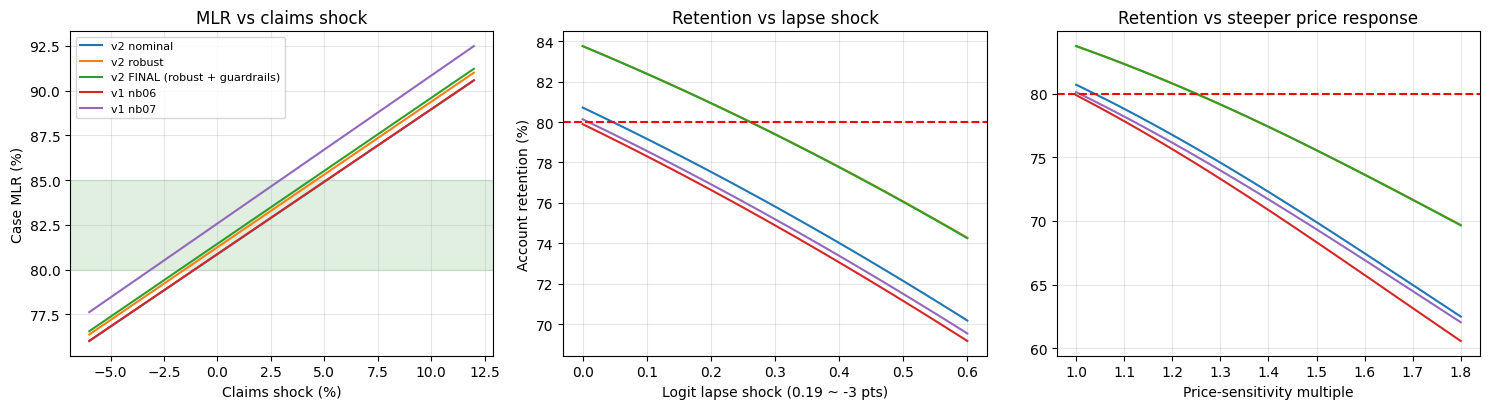

In [4]:
claims_grid, delta_grid, elastic_grid = np.round(np.arange(.94, 1.1201, .005), 3), np.arange(0, .61, .01), np.round(np.arange(1, 1.81, .02), 2)
bp, curves = [], {}
for sol, ch in solutions.items():
    base = portfolio_metrics(ch, P, prem0, claims0)
    mlr_c = np.array([portfolio_metrics(ch, P, prem0, claims0, c)['case_mlr'] for c in claims_grid])
    ret_d = np.array([stress.shift(d)[i, ch].mean() for d in delta_grid])
    ret_e = np.array([stress.elastic(k)[i, ch].mean() for k in elastic_grid])
    curves[sol] = (mlr_c, ret_d, ret_e)
    bp.append(dict(solution=sol, base_retention=base['account_retention'], base_mlr=base['case_mlr'],
                   max_claims_increase_before_85pct=0.85 / base['case_mlr'] - 1,
                   max_claims_decrease_before_80pct=1 - 0.80 / base['case_mlr'],
                   retention_headroom_pts=100 * (base['account_retention'] - .80),
                   max_price_sensitivity_multiple=elastic_grid[ret_e >= .80].max() if (ret_e >= .80).any() else np.nan))
bp = pd.DataFrame(bp); bp.to_csv(OUT / 'breakpoints.csv', index=False); display(bp.round(4))
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for sol, (mlr_c, ret_d, ret_e) in curves.items():
    ax[0].plot(100 * (claims_grid - 1), 100 * mlr_c, label=sol); ax[1].plot(delta_grid, 100 * ret_d, label=sol); ax[2].plot(elastic_grid, 100 * ret_e, label=sol)
ax[0].axhspan(80, 85, color='g', alpha=.12); ax[0].set_xlabel('Claims shock (%)'); ax[0].set_ylabel('Case MLR (%)'); ax[0].set_title('MLR vs claims shock')
ax[1].axhline(80, color='r', ls='--'); ax[1].set_xlabel('Logit lapse shock (0.19 ~ -3 pts)'); ax[1].set_ylabel('Account retention (%)'); ax[1].set_title('Retention vs lapse shock')
ax[2].axhline(80, color='r', ls='--'); ax[2].set_xlabel('Price-sensitivity multiple'); ax[2].set_title('Retention vs steeper price response')
for a in ax: a.grid(alpha=.3)
ax[0].legend(fontsize=8); fig.tight_layout(); fig.savefig(OUT / 'plots' / '01_breakpoints.png', dpi=170); plt.show()

## 4 · Monte Carlo: probability that the limits actually hold
Each simulation draws (a) a renewal-model parameter vector from the FY2023–FY2025 fit's covariance, (b) a Bernoulli renew/lapse outcome for every account, and (c) account-level claims process noise (Poisson bootstrap cv of each account's FY2025 episodes). 300 × 10 = 3,000 simulations per solution. No trend (primary case).

,solution,sims,retention_mean,retention_p05,mlr_mean,mlr_p05,mlr_p95,contribution_mean,contribution_p05,prob_retention_ok,prob_mlr_ok,prob_all_limits_ok
0,v2 nominal,3000,0.8056,0.7949,0.8085,0.8004,0.8163,2.632765e+09,2.513558e+09,0.8050,0.9560,0.7747
1,v2 robust,3000,0.8361,0.8262,0.8124,0.8044,0.8200,2.609508e+09,2.493641e+09,1.0000,0.9923,0.9923
2,v2 FINAL (robust + guardrails),3000,0.8360,0.8263,0.8144,0.8065,0.8218,2.582625e+09,2.467432e+09,1.0000,0.9977,0.9977
3,v1 nb06,3000,0.7973,0.7864,0.8086,0.8002,0.8165,2.603064e+09,2.480358e+09,0.3563,0.9543,0.3450
4,v1 nb07,3000,0.7999,0.7900,0.8260,0.8189,0.8332,2.370554e+09,2.254452e+09,0.5000,1.0000,0.5000


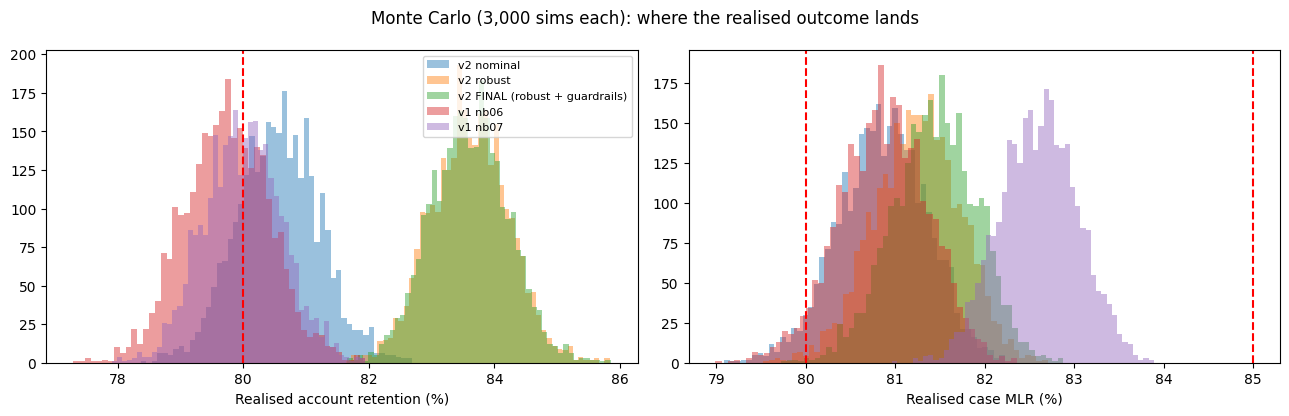

In [5]:
mc_rows, mc_draws = [], {}
for sol, ch in solutions.items():
    r = monte_carlo(ch, Zg, draws, prem0, claims0, cv, n_bern=10, seed=11); mc_draws[sol] = r
    mc_rows.append({'solution': sol, **summarise_mc(r)})
mc = pd.DataFrame(mc_rows); mc.to_csv(OUT / 'monte_carlo_summary.csv', index=False); display(mc.round(4))
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for sol, r in mc_draws.items():
    ax[0].hist(100 * r['account_retention'], bins=50, alpha=.45, label=sol); ax[1].hist(100 * r['case_mlr'], bins=50, alpha=.45, label=sol)
ax[0].axvline(80, color='r', ls='--'); ax[0].set_xlabel('Realised account retention (%)'); ax[0].legend(fontsize=8)
ax[1].axvline(80, color='r', ls='--'); ax[1].axvline(85, color='r', ls='--'); ax[1].set_xlabel('Realised case MLR (%)')
fig.suptitle('Monte Carlo (3,000 sims each): where the realised outcome lands'); fig.tight_layout(); fig.savefig(OUT / 'plots' / '02_monte_carlo.png', dpi=170); plt.show()

## 5 · B4 trend as a separate alternative (README: trend is not part of the primary case)
Two views: (a) the recommended no-trend rates if trend arrives anyway (a monitoring trigger), and (b) rates re-optimised on B4-trended claims with the same robust constraints — the rate load the client would need if it chose to price for trend.

In [6]:
claims_tr = claims0 * trend
FINAL = 'v2 FINAL (robust + guardrails)'
risk = snap['risk_score_2025'].to_numpy(); avg_risk = risk.mean()
guard_rows = [('premium_weighted_retention', prem0[:, None] * P, 0.80 * prem0.sum(), np.inf),
              ('risk_mix_upper', P * (risk - 1.15 * avg_risk)[:, None], -np.inf, 0.0), ('risk_mix_lower', P * (0.85 * avg_risk - risk)[:, None], -np.inf, 0.0)]
top50 = np.zeros(N, bool); top50[np.argsort(-prem0)[:50]] = True
allow_top50 = ~(top50[:, None] & (RATES[None, :] > 15)); penalty25 = 0.005 * prem0[:, None] * (RATES[None, :] == 25)
# (b1) can the 80-85% corridor be reached at all under B4 trend, with the brief's limits + guardrails?
x_tr, ch_tr, info_tr = solve_rate_mip(P, prem0, claims_tr, extra_rows=guard_rows, allowed=allow_top50, objective_penalty=penalty25)
print('B4-trended claims, brief limits + guardrails:', info_tr['solver_status'])
views = [{'view': 'FINAL no-trend rates, B4 trend arrives (monitoring trigger)', **portfolio_metrics(solutions[FINAL], P, prem0, claims_tr)}]
if info_tr['solver_status'] == 'Optimal':
    views.append({'view': 'rates re-optimised for B4 trend (brief limits + guardrails)', **portfolio_metrics(ch_tr, P, prem0, claims_tr)})
else:
    # (b2) corridor unreachable: best achievable within retention >= 80% and guardrails (MLR ceiling released) - shows the gap
    x_tr, ch_tr, info_tr = solve_rate_mip(P, prem0, claims_tr, U=10.0, extra_rows=guard_rows, allowed=allow_top50, objective_penalty=penalty25)
    views.append({'view': 'B4 trend: corridor NOT reachable within +25% cap; best plan with retention>=80% + guardrails', **portfolio_metrics(ch_tr, P, prem0, claims_tr), 'solver_status': info_tr['solver_status']})
trend_view = pd.DataFrame(views); trend_view.to_csv(OUT / 'b4_trend_alternative.csv', index=False)
display(trend_view[['view', 'account_retention', 'case_mlr', 'expected_contribution', 'avg_rate_premium_weighted', 'accounts_at_cap']].round(4))
pd.DataFrame({'account_id': snap['account_id'], 'rate_no_trend': RATES[solutions[FINAL]], 'rate_b4_trend': RATES[ch_tr]}).to_csv(OUT / 'b4_trend_rates_by_account.csv', index=False)

B4-trended claims, brief limits + guardrails: Infeasible


,view,account_retention,case_mlr,expected_contribution,avg_rate_premium_weighted,accounts_at_cap
0,"FINAL no-trend rates, B4 trend arrives (monito...",0.8375,0.8698,1.815124e+09,12.0398,1211
1,B4 trend: corridor NOT reachable within +25% c...,0.8006,0.8650,1.852689e+09,13.8393,1448


,primary-case scenarios meeting retention>=80% and MLR<=85%,scenarios
solution,,
v1 nb06,2,11
v1 nb07,3,11
v2 FINAL (robust + guardrails),7,11
v2 nominal,5,11
v2 robust,7,11


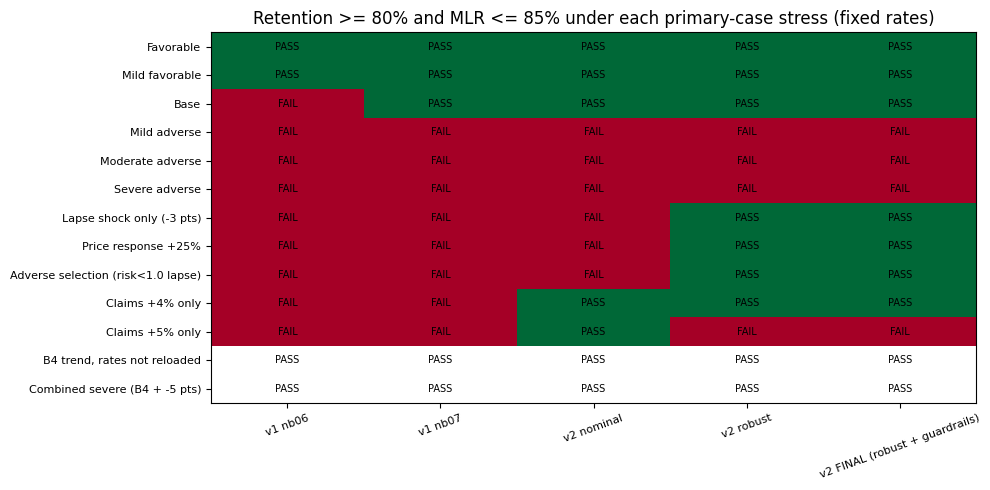

written


In [7]:
summary = det.copy()
summary['limits_met'] = summary['retention_pass'] & summary['mlr_ceiling_pass']
count = summary[summary.family.isin(['base', 'combined', 'renewal', 'claims'])].groupby('solution')['limits_met'].agg(['sum', 'size'])
count.columns = ['primary-case scenarios meeting retention>=80% and MLR<=85%', 'scenarios']
display(count)
hm = summary[summary.family.isin(['base', 'combined', 'renewal', 'claims'])].pivot(index='scenario', columns='solution', values='limits_met').reindex([x for x in order if x in set(summary.scenario)])
hm = hm[[c for c in ['v1 nb06', 'v1 nb07', 'v2 nominal', 'v2 robust', 'v2 FINAL (robust + guardrails)'] if c in hm.columns]]
fig, ax = plt.subplots(figsize=(10, 5)); ax.imshow(hm.astype(float).values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(hm.shape[1]), hm.columns, rotation=20, fontsize=8); ax.set_yticks(range(hm.shape[0]), hm.index, fontsize=8)
for (r, c), v in np.ndenumerate(hm.values): ax.text(c, r, 'PASS' if v else 'FAIL', ha='center', va='center', fontsize=7)
ax.set_title('Retention >= 80% and MLR <= 85% under each primary-case stress (fixed rates)'); fig.tight_layout(); fig.savefig(OUT / 'plots' / '03_stress_pass_fail_heatmap.png', dpi=170); plt.show()
hm.to_csv(OUT / 'stress_pass_fail_matrix.csv')
readme = f"""# v2 stress-test summary

Primary case: FY2025 paid claims carried forward, no trend. B4 trend reported separately.

## Scenarios meeting both limits (retention >= 80%, MLR <= 85%)
{count.to_string()}

## Breakpoints
{bp.round(4).to_string(index=False)}

## Monte Carlo
{mc.round(4).to_string(index=False)}

## B4 trend alternative
{trend_view[['view', 'account_retention', 'case_mlr', 'expected_contribution', 'avg_rate_premium_weighted', 'accounts_at_cap']].round(4).to_string(index=False)}
"""
(OUT / 'README_stress_v2.md').write_text(readme, encoding='utf-8'); print('written')